# WT vs KO expression check

checking expression of certain genes to confirm that Mixl1 KO is indeed the KO

### Load packages

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
})

### I/O

In [46]:
in_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"

In [3]:
big_sce <- readRDS(paste0(in_folder, "big_sce_norm.rds"))
big_meta = read.table(paste0(in_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
gene_meta =  read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/gene_id_name_conversion.csv", header = TRUE, sep = ",")
gene_meta = gene_meta %>% select(gene_id, gene_name)

In [4]:
meta = big_meta %>% filter(tdTom != 'NA') %>% select(cell, sample, tdTom)
chim = big_sce[,meta$cell]

In [5]:
rm(big_sce)

In [6]:
counts = as.data.frame(chim@assays@data$logcounts)
counts$gene_id = rownames(counts)
counts = merge(counts, gene_meta, by='gene_id')

In [7]:
for(i in unique(meta$sample)){
print(paste0('cells for sample ', i, ': ' ,nrow(filter(meta, sample == i))))
}

[1] "cells for sample mixl_1: 6756"
[1] "cells for sample mixl_2: 8941"
[1] "cells for sample mixl_3: 3964"
[1] "cells for sample mixl_4: 3168"
[1] "cells for sample mixl_5: 7387"
[1] "cells for sample mixl_6: 6992"


In [47]:
genes = c('Mixl1', 'Xist')

plots = list()

for(i in 1:length(genes)){
filter_genes = counts %>% filter(gene_name == genes[[i]]) %>% select(-gene_id, -gene_name)
filter_genes = gather(filter_genes, cell, gene)
plot = merge(meta, filter_genes, by='cell')

plots[[i]] <- ggplot(plot, aes(sample, log(gene+1), fill=tdTom)) + 
            geom_violin(scale = 'width') +
            geom_boxplot(width=0.3, fill="white") +
            geom_point(position = position_jitterdodge(jitter.width = 1),
                size = 0.05, alpha = 0.5) +
            scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
            labs(y = "log logCounts") +
            ggtitle(genes[[i]])+
            theme_classic()
}
   

Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”


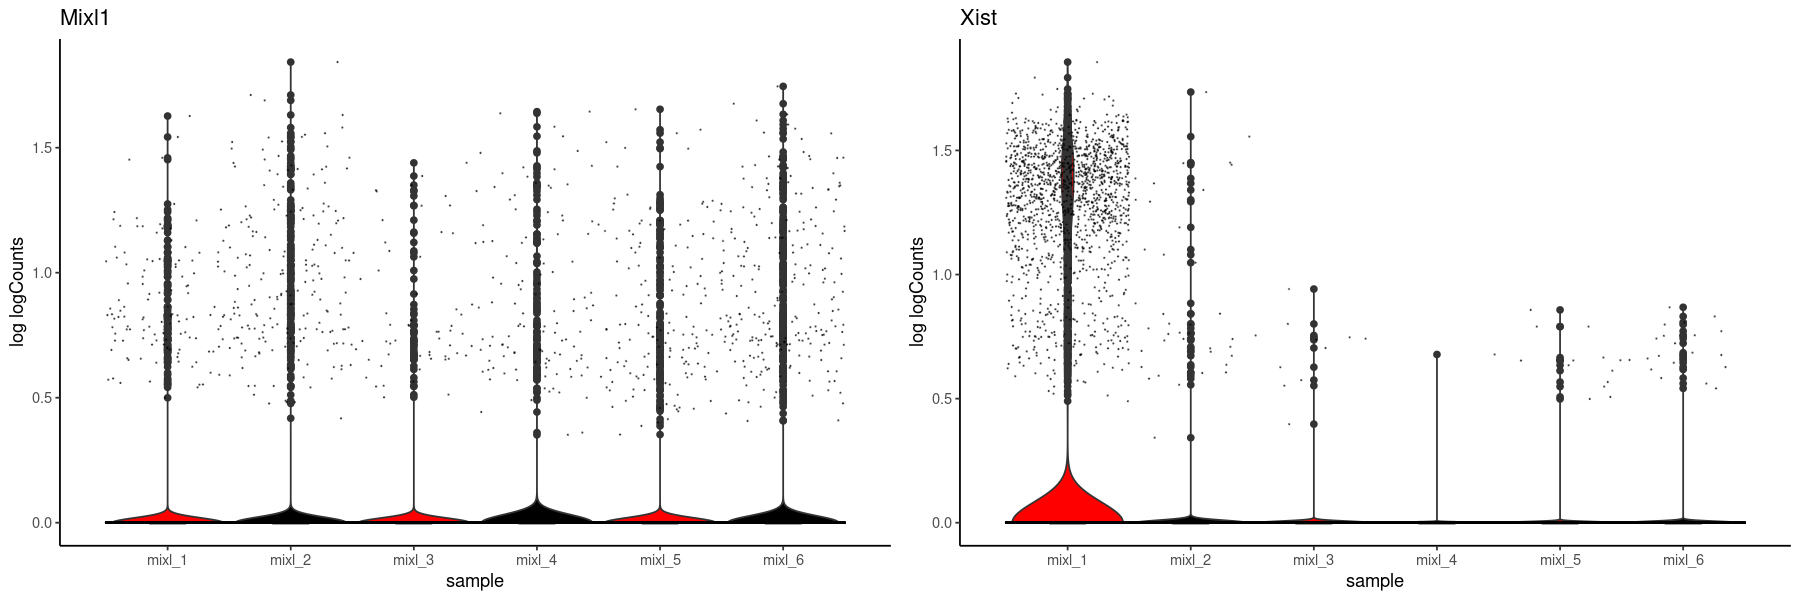

In [48]:
options(repr.plot.width=15, repr.plot.height=5)
CombinePlots(plots = plots, ncol = 2, legend = "none")

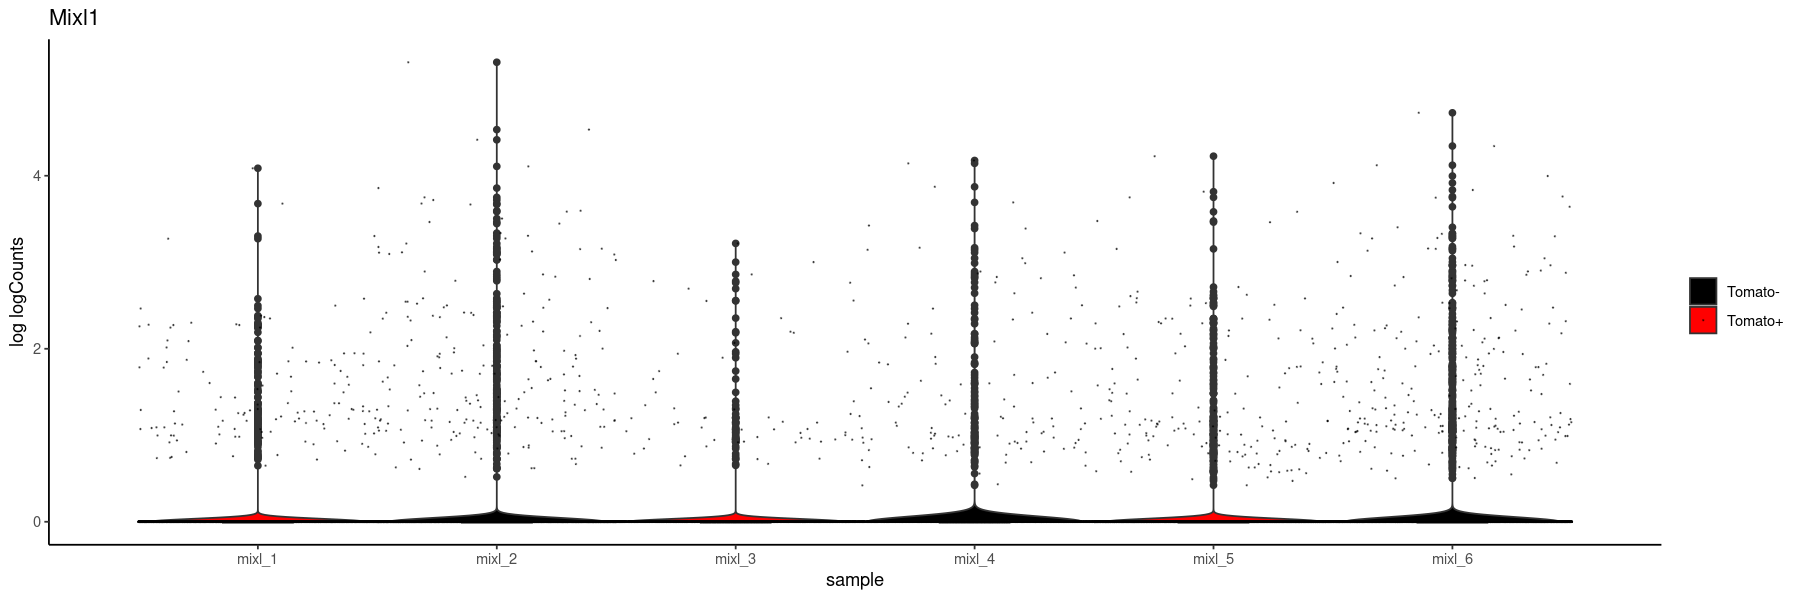

In [40]:
plots[[1]]

In [91]:
head(meta)

,cell,sample,tdTom
,<chr>,<chr>,<chr>
1,chim_cell_1,mixl_1,pos
2,chim_cell_2,mixl_1,pos
3,chim_cell_3,mixl_1,pos
4,chim_cell_4,mixl_1,pos
5,chim_cell_5,mixl_1,pos
6,chim_cell_6,mixl_1,pos


In [6]:
counts = as.data.frame(chim@assays@data$logcounts) # count or logcounts
counts$gene_id = rownames(counts)
counts = merge(counts, gene_meta, by='gene_id')
counts$gene_id = NULL
counts = counts %>% distinct(gene_name, .keep_all=TRUE)
rownames(counts) = counts$gene_name
counts$gene_name = NULL
counts = as.data.frame(t(counts))
counts$cell = rownames(counts)
all = merge(counts, meta, by='cell')

In [19]:
dim(all)
head(all)

[1] 37208 31020

,cell,Gnai3,Pbsn,Cdc45,H19,Scml2,Apoh,Narf,Cav2,Klf6,⋯,AC165344.1,AC154242.1,AC125199.4,CT030713.2,AC150035.3,AC164314.2,AC131339.4,AC135964.2,sample,tdTom
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,chim_cell_1,0.8619360,0,0.000000,1.7876109,0,0,0,0,0.861936,⋯,0,0,0,0,0,0,0,0,mixl_1,neg
2,chim_cell_10,2.8115955,0,0.000000,2.4634797,0,0,0,0,0.000000,⋯,0,0,0,0,0,0,0,0,mixl_1,neg
3,chim_cell_100,0.8940245,0,0.000000,0.8940245,0,0,0,0,0.000000,⋯,0,0,0,0,0,0,0,0,mixl_1,neg
4,chim_cell_1000,0.0000000,0,0.000000,3.8490692,0,0,0,0,0.000000,⋯,0,0,0,0,0,0,0,0,mixl_1,neg
5,chim_cell_10000,1.9430711,0,1.276566,2.1879392,0,0,0,0,0.000000,⋯,0,0,0,0,0,0,0,0,mixl_2,pos
6,chim_cell_10001,0.6729098,0,0.000000,4.1407775,0,0,0,0,0.000000,⋯,0,0,0,0,0,0,0,0,mixl_2,pos


In [54]:
xist = ggplot(all, aes(sample, Xist, fill=sample)) +
                    geom_violin(scale = 'width') +
                    geom_point(
                       position = position_jitterdodge(jitter.width = 0.5),
                       size =1, alpha = 1) +
                    theme_classic() + 
                    labs(x = "sample", y = "Normalised expression") +
                    ggtitle('Xist') +
                    theme(text = element_text(size = 40), axis.text.x = element_text(angle = -30, hjust = 0), legend.position = "none") 

mixl = ggplot(all, aes(sample, Mixl1, fill=sample)) +
                    geom_violin(scale = 'width') +
                    geom_point(
                       position = position_jitterdodge(jitter.width = 0.5),
                       size =1, alpha = 1) +
                    theme_classic() + 
                    labs(x = "sample", y = "Normalised expression") +
                    ggtitle('Mixl1') +
                    theme(text = element_text(size = 40), axis.text.x = element_text(angle = -30, hjust = 0), legend.position = "none",axis.title.x=element_blank()) 


png 
  2

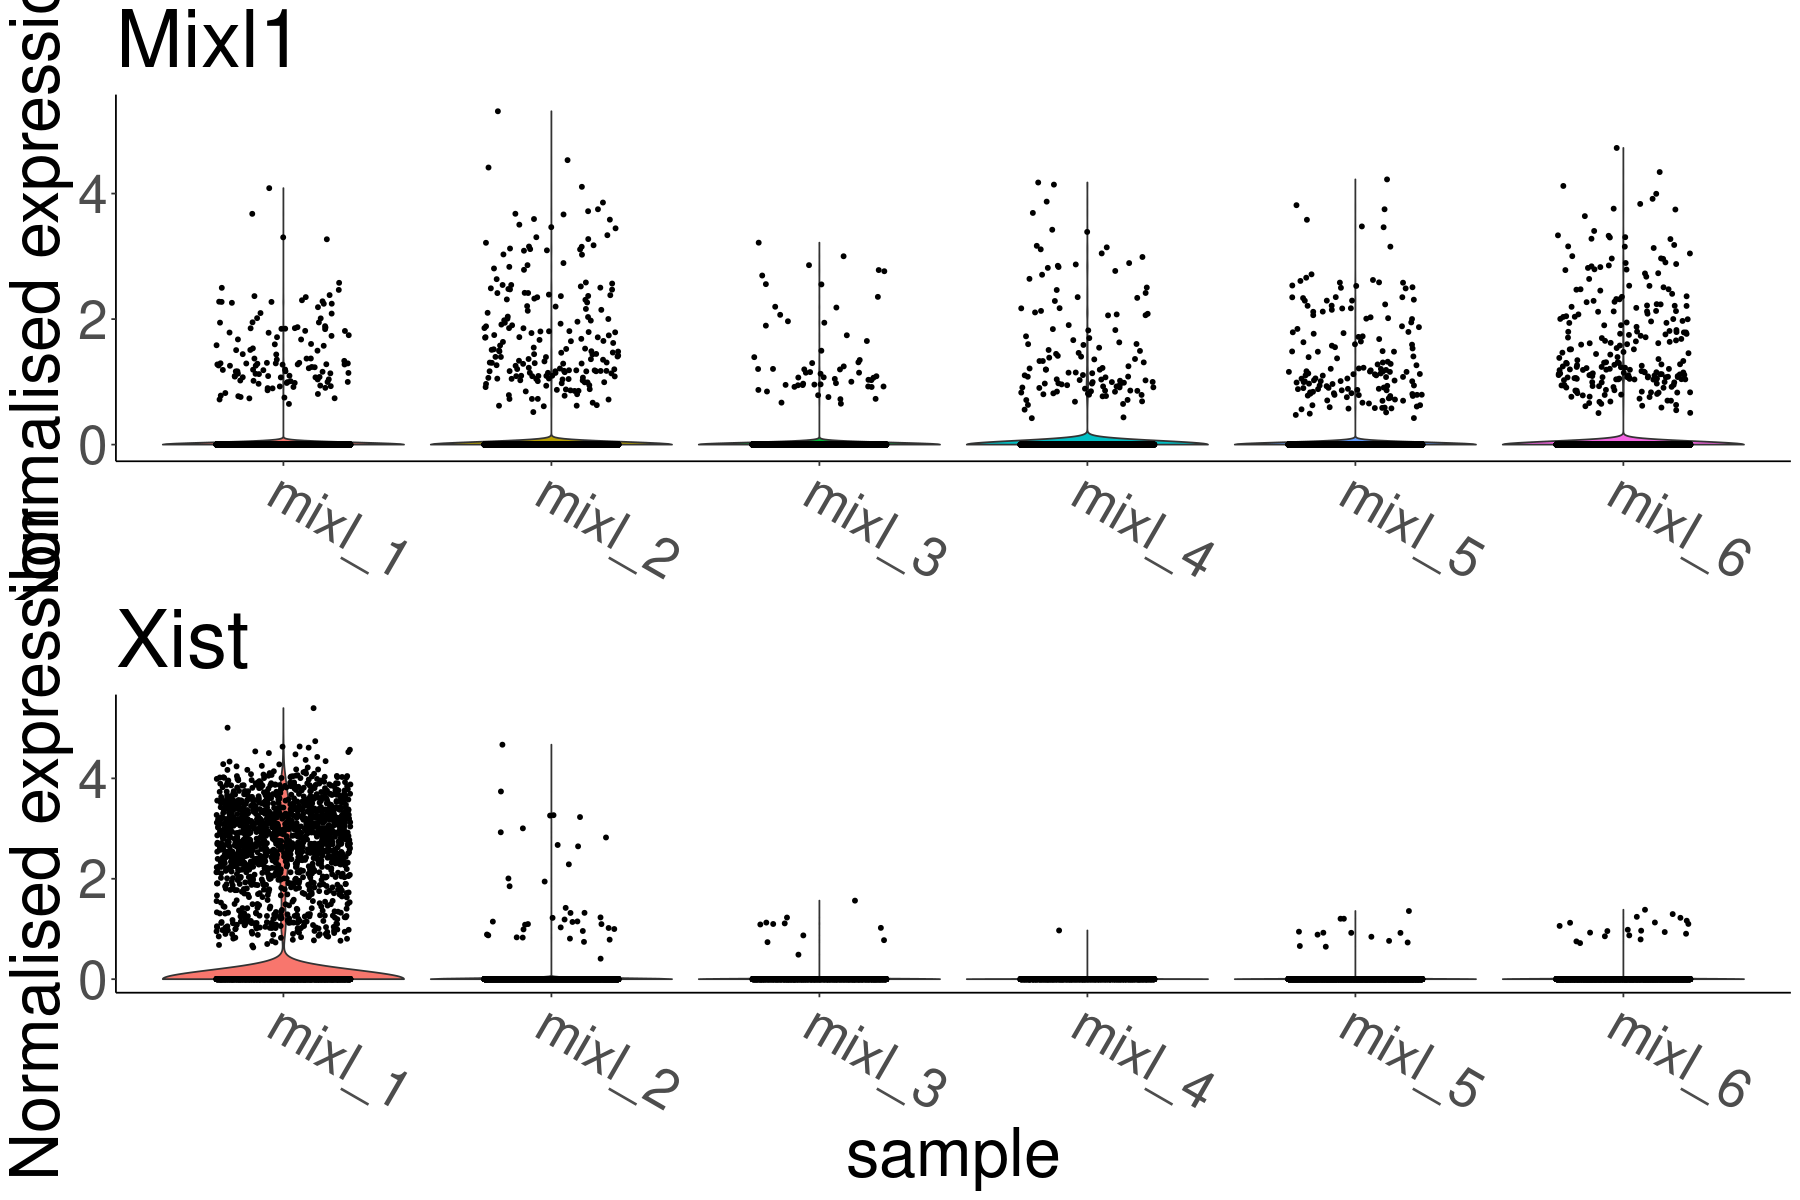

In [56]:
options(repr.plot.width=15, repr.plot.height=10)
grid.arrange(plots = mixl, xist)

png(paste0(plot_folder, "xist_mixl_expression.png"), height=1100, width=1000)
    grid.arrange(plots = mixl, xist)
dev.off()

In [22]:
genes = c('Mixl1', 'Xist')

plots = list()

for(i in 1:length(genes)){
filter_genes = counts %>% filter(gene_name == genes[[i]]) %>% select(-gene_id, -gene_name)
filter_genes = gather(filter_genes, cell, gene)
plot = merge(meta, filter_genes, by='cell')
#plot = plot %>% filter(gene > 0)
    
plots[[i]] = ggplot(plot, aes(gene, fill=tdTom)) + 
        geom_histogram(bins=30) + 
        facet_wrap(~sample, scales='free_y') + 
        scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                        labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                        name = "") +
        theme_classic() +
        ggtitle(genes[[i]])
}

Warning message:
“CombinePlots is being deprecated. Plots should now be combined using the patchwork system.”


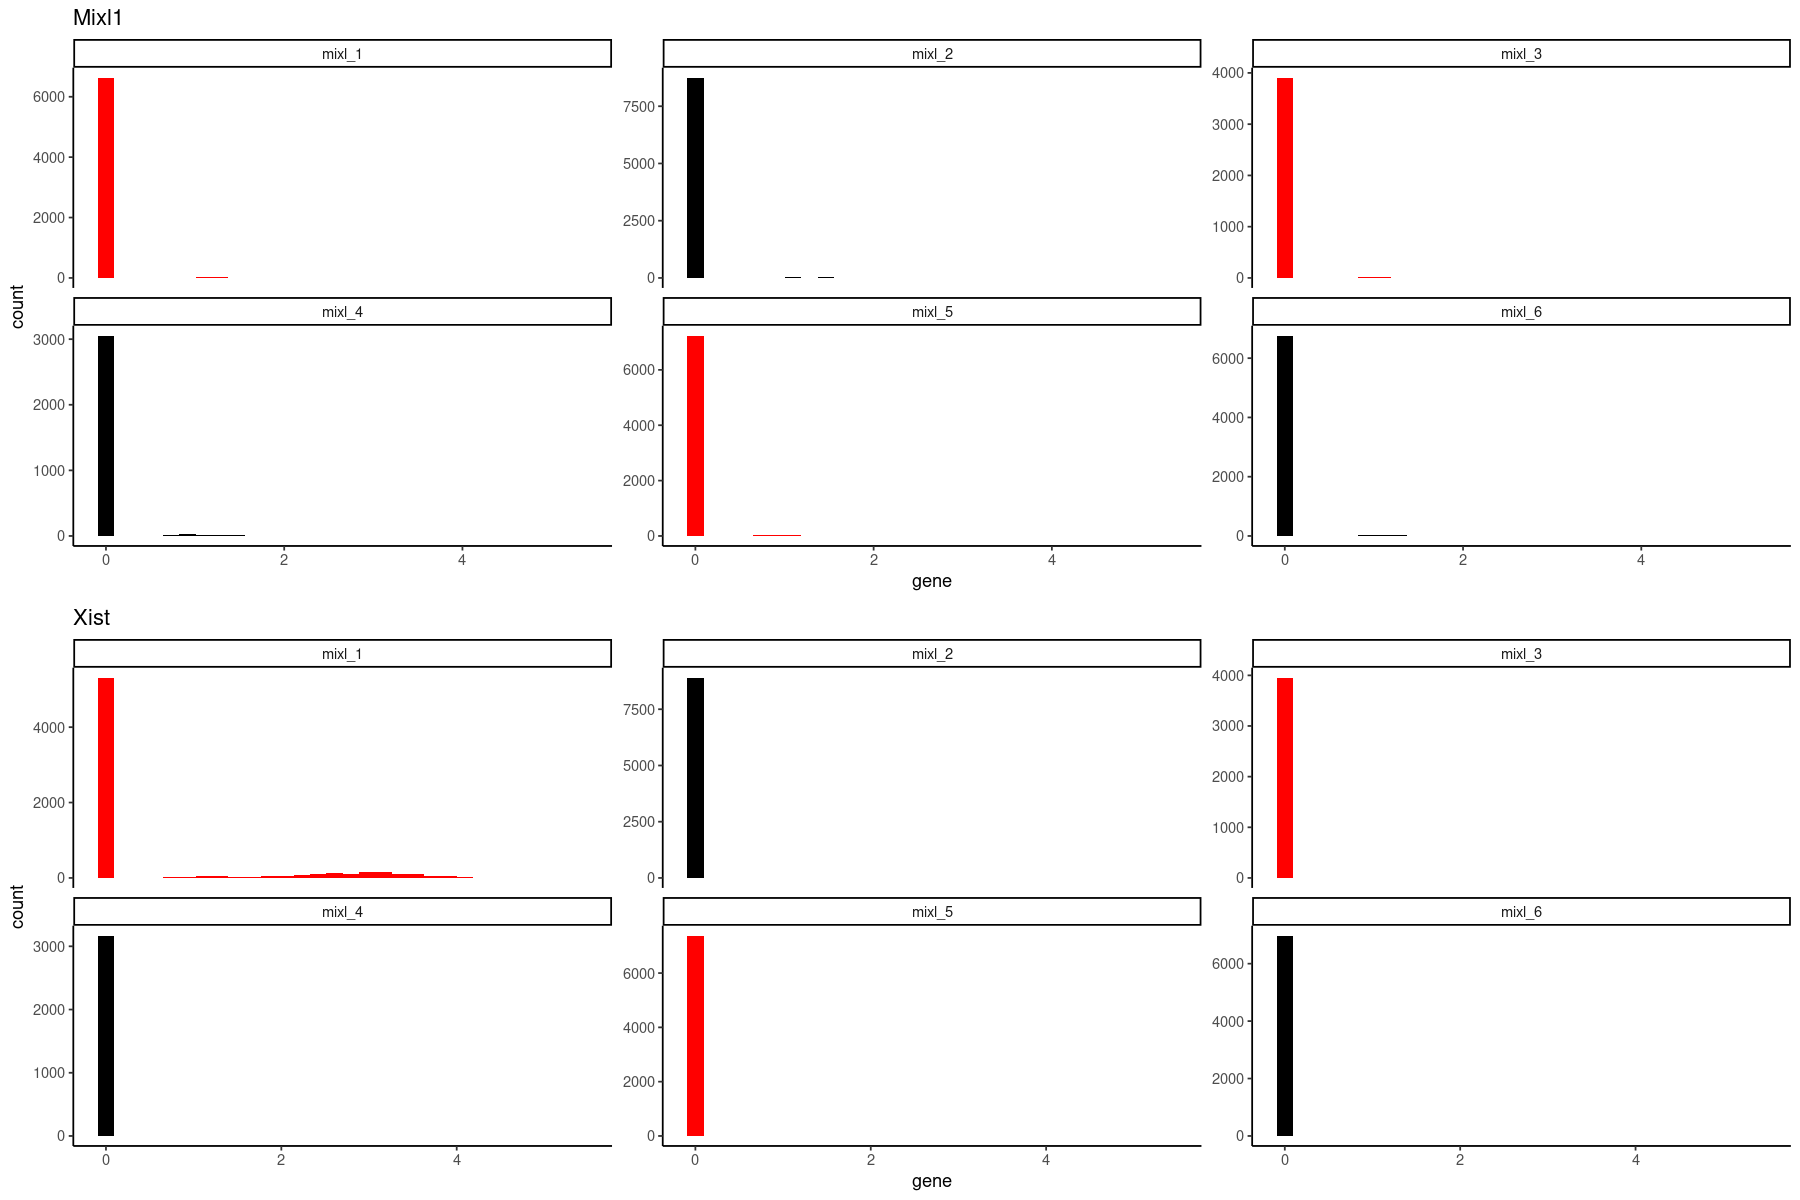

In [23]:
options(repr.plot.width=15, repr.plot.height=10)
CombinePlots(plots = plots, ncol = 1, legend = "none")

In [7]:
counts2 = counts

In [ ]:
counts = counts2

In [9]:
counts$gene_id = NULL
counts = counts[unique(counts$gene_name)]
rownames(counts) = counts$gene_name
counts = t(counts)

ERROR: Error in `[.data.frame`(counts, unique(counts$gene_name)): undefined columns selected


In [11]:
head(unique(counts$gene_name))

[1] "Gnai3" "Pbsn"  "Cdc45" "H19"   "Scml2" "Apoh"

In [10]:
head(counts)

,chim_cell_1,chim_cell_2,chim_cell_3,chim_cell_4,chim_cell_5,chim_cell_6,chim_cell_8,chim_cell_9,chim_cell_10,chim_cell_11,⋯,chim_cell_43815,chim_cell_43816,chim_cell_43817,chim_cell_43818,chim_cell_43819,chim_cell_43821,chim_cell_43822,chim_cell_43824,chim_cell_43825,gene_name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0.861936,0.0000,1.4041192,0,0,0,1.591293,1.644719,2.811596,1.544716,⋯,1.695793,0.000000,0.9745413,0.8881527,1.557181,1.633607,1.132178,1.980992,2.688638,Gnai3
2,0.000000,0.0000,0.0000000,0,0,0,0.000000,0.000000,0.000000,0.000000,⋯,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,Pbsn
3,0.000000,0.0000,0.8665367,0,0,0,0.000000,1.644719,0.000000,0.000000,⋯,0.000000,1.095826,0.9745413,0.0000000,1.557181,0.000000,0.000000,0.000000,0.000000,Cdc45
4,1.787611,2.3562,2.1020275,0,0,0,2.670957,0.000000,2.463480,3.750985,⋯,4.761715,2.141453,3.8589983,5.1652285,1.968707,2.645516,0.000000,4.548567,3.046618,H19
5,0.000000,0.0000,0.0000000,0,0,0,0.000000,0.000000,0.000000,0.000000,⋯,0.000000,0.000000,0.0000000,0.8881527,0.000000,0.000000,0.000000,0.000000,0.000000,Scml2
6,0.000000,0.0000,0.0000000,0,0,0,0.000000,0.000000,0.000000,0.000000,⋯,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,Apoh


In [ ]:
test = gather(counts, cell, gene)

In [ ]:
head(test)